In [ ]:
using DataFrames
using JSON
using LinearAlgebra
using Plots
using Turing

In [2]:
DATA = "../../data"

"../../data"

In [3]:
englandleague = JSON.parsefile("$DATA/matches_England.json")
matchesdf = DataFrame(home=[], away=[], scorehome=[], scoreaway=[])

,home,away,scorehome,scoreaway
,Any,Any,Any,Any


In [4]:
englandleague[1]

Dict{String,Any} with 14 entries:
  "label"         => "Burnley - AFC Bournemouth, 1 - 2"
  "teamsData"     => Dict{String,Any}("1646"=>Dict{String,Any}("coachId"=>8880,…
  "wyId"          => 2500089
  "duration"      => "Regular"
  "status"        => "Played"
  "venue"         => "Turf Moor"
  "roundId"       => 4405654
  "winner"        => 1659
  "gameweek"      => 38
  "date"          => "May 13, 2018 at 4:00:00 PM GMT+2"
  "competitionId" => 364
  "dateutc"       => "2018-05-13 14:00:00"
  "seasonId"      => 181150
  "referees"      => Any[Dict{String,Any}("role"=>"referee","refereeId"=>385705…

In [5]:
matches = []
for match in englandleague
    push!(matches, split(match["label"], ","))
end

In [6]:
for match in matches
    home, away = split(match[1], " - ")
    scorehome, scoreaway = split(match[2], " - ")
    push!(matchesdf, 
          [home, away, parse(Int, scorehome), parse(Int, scoreaway)])
end

In [7]:
first(matchesdf, 5)

,home,away,scorehome,scoreaway
,Any,Any,Any,Any
1,Burnley,AFC Bournemouth,1,2
2,Crystal Palace,West Bromwich Albion,2,0
3,Huddersfield Town,Arsenal,0,1
4,Liverpool,Brighton & Hove Albion,4,0
5,Manchester United,Watford,1,0


In [8]:
teams = unique(collect(matchesdf[:, :home]))

20-element Array{Any,1}:
 "Burnley"
 "Crystal Palace"
 "Huddersfield Town"
 "Liverpool"
 "Manchester United"
 "Newcastle United"
 "Southampton"
 "Swansea City"
 "Tottenham Hotspur"
 "West Ham United"
 "Manchester City"
 "Leicester City"
 "Chelsea"
 "Arsenal"
 "Everton"
 "AFC Bournemouth"
 "Watford"
 "West Bromwich Albion"
 "Stoke City"
 "Brighton & Hove Albion"

### Create the Model

In [9]:
@model function games(hometeams, awayteams, scorehome, scoreaway, teams)
    # hyper priors
    sigatt ~ Exponential(1)
    sigdef ~ Exponential(1)
    muatt ~ Normal(0, 0.1)
    mudef ~ Normal(0, 0.1)
    home ~ Normal(0, 1)
    
    # Team-specific effects
    att ~ filldist(Normal(muatt, sigatt), length(teams))
    def ~ filldist(Normal(mudef, sigdef), length(teams))
    dict = Dict{String, Int64}()
    for (i, team) in enumerate(teams)
        dict[team] = i
    end
    
    # Zero-sum constraints
    offset = mean(att) + mean(def)
    logthetahome = Vector{Real}(undef, length(hometeams))
    logthetaaway = Vector{Real}(undef, length(awayteams))
    
    # Modeling score-rate and scores
    for i in 1:length(hometeams)
        # score rates
        logthetahome[i] = (home 
                           + att[dict[hometeams[i]]] 
                           + def[dict[awayteams[i]]]
                           - offset)
        logthetaaway[i] = (
            att[dict[awayteams[i]]] + def[dict[hometeams[i]]] - offset)
        # scores
        scorehome[i] ~ LogPoisson(logthetahome[i])
        scoreaway[i] ~ LogPoisson(logthetaaway[i])
    end
end

games (generic function with 1 method)

In [10]:
model = games(matchesdf[:, :home], 
              matchesdf[:, :away],
              matchesdf[:, :scorehome], 
              matchesdf[:, :scoreaway], 
              teams);

In [11]:
posterior = sample(model, NUTS(), 3000);

┌ Info: Found initial step size
│   ϵ = 0.05
└ @ Turing.Inference /Users/dsatterthwaite/.julia/packages/Turing/PyTy2/src/inference/hmc.jl:188
Sampling: 100%|█████████████████████████████████████████| Time: 0:09:46


### Analyzing the Results

In [12]:
postatt = collect(get(posterior, :att)[1])
postdef = collect(get(posterior, :def)[1])
posthome = collect(get(posterior, :home)[1]);

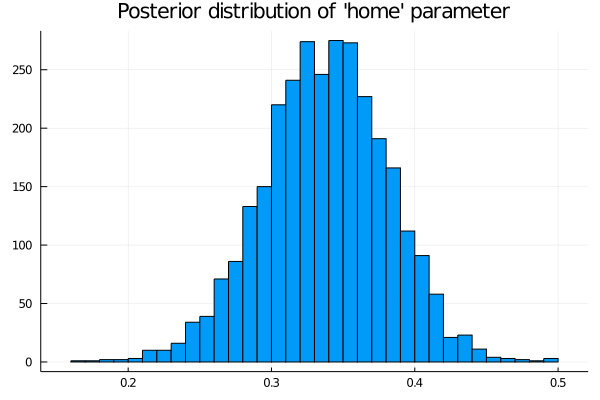

In [13]:
gr()
histogram(posthome, 
          legend=false, 
          title="Posterior distribution of 'home' parameter")

In [14]:
mean(posthome)

0.3375598644059831

In [15]:
teamsatt = []
teamsdef = []
for i in 1:length(postatt)
    push!(teamsatt, postatt[i])
    push!(teamsdef, postdef[i])
end;

...Grr... kernel always dies here...

In [ ]:
histogram(teamsatt[1], 
          legend=false, 
          title="Posterior of $(teamsatt[1])'s attack power")

In [ ]:
mean(teamsatt[1])

In [ ]:
histogram(teamsatt[11], 
          legend=false, 
          title="Posterior of $(teamsatt[1])'s attack power")

In [ ]:
mean(teamsatt[11])

In [ ]:
teamsattmu = mean.(teamsatt)
teamsdefmu = mean.(teamsdef)
teamsattsig = std.(teamsatt)
teamsdefsig = std.(teamsdef);

In [ ]:
sortedatt = sortperm(teamsattmu)
abbrnames = [t[1:3] for t in teams]
sortednames = abbrnames[sortedatt]

In [ ]:
scatter(1:20, 
        teamsattmu[sortedatt], 
        grid=false, 
        legend=false, 
        yerror=teamsattsig[sortedatt], 
        color=:blue, 
        title="Premier league teams attack power")
annotate!(
    [(x, y + 0.238, text(team, 8, :center, :black)) 
     for (x, y, team) in zip(1:20, teamsattmu[sortedatt], sortednames)])
ylabel!("Mean team attack")

In [ ]:
sorteddef = sortperm(teamsdefmu)
sortednamesdef = abbrnames[sorteddef]

In [ ]:
scatter(1:20, 
        teamsdefmu[sorteddef], 
        grid=false, 
        legend=false, 
        yerror=teamdefsig[sorteddef], 
        color=:blue, 
        title="Premier league teams defense power")
annotate!(
    [(x, y + 0.238, text(team, 8, :center, :black)) 
     for (x, y, team) in zip(1:20, teamsdefmu[sorteddef], sortednames)])
ylabel!("Mean team defense")

In [ ]:
tableposition [
    11, 5, 9, 4, 13, 14, 1, 15, 12, 6, 2, 16, 10, 17, 20, 3, 7, 8, 19, 18]
position = sortperm(tableposition)

In [ ]:
scatter(teamsattmu, temasdefmu, legend=false)
annotate!([(x, y + 0.016, text(team, 6, :center, :black)) 
           for (x, y, team) in zip(teamsattmu, teamsdefmu, abbrnames)])
annotate!([(x, y - 0.016, text(team, 5, :center, :black)) 
           for (x, y, team) in zip(teamsattmu, teamsdefmu, abbrnames)])
xlabel!("Mean team attack")
ylabel!("Mean team defense")

In [ ]:
mciattpost = collect(get(posterior, :att)[:att])[11][:, 1]
mcidefpost = collect(get(posterior, :def)[:def])[11][:, 1]
livattpost = collect(get(posterior, :att)[:att])[4][:, 1]
livdefpost = collect(get(posterior, :def)[:def])[4][:, 1]

In [ ]:
hist1 = histogram(mciattpost, title="Manchester Attack", legend=false)
hist2 = histogram(livattpost, title="Liverpool Attack", legend=false)
plot(hist1, hist2, layout=(1, 2))

In [ ]:
hist1 = histogram(mcidefpost, title="Manchester Defense", legend=false)
hist2 = histogram(livdefpost, title="Liverpool Defense", legend=false)
plot(hist1, hist2, layout=(1, 2))

In [1]:
function simulatematches_(
        att1, def1, att2, def2, home, nmatches, hometeam=1)
    logtheta1 = att1 + def1
    logtheta2 = att2 + def2
    hometeam == 1 ? logtheta1 += home : logtheta2 += 1
    scores1 = rand(LogPoisson(logtheta1), nmatches)
    scores2 = rand(LogPoisson(logtheta2), nmatches)
    res = [(s1, s2) for (s1, s2) in zip(scores1, scores2)]
    res
end

simulatematches_ (generic function with 2 methods)

In [3]:
function simulatematches(
        t1attpost, t1defpost, t2attpos, t2defpost, homepost, nmatches)
    t1ashomeres = Tuple{Int64, Int64}[]
    t2ashomeres = Tuple{Int64, Int64}[]
    for (t1att, t1def, t2att, t2def, home) in zip(
            t1attpost, t1defpost, t2attpost, t2defpost, homepost)
        t1ashomeres = vcat(
            t1ashomeres, 
            simulatematches_(
                t1att, t1def, t2att, t2def, home, nmatches, 1))
        t2ashomeres = vcat(
            t2ashomeres, 
            simulatematches_(
                t1att, t1def, t2att, t2def, home, nmatches, 2))
    end
    max_t1ashome = maximum(map(x -> x[1], team1ashomeres))
    max_t1asaway = maximum(map(x -> x[2], team1ashomeres))
    max_t2ashome = maximum(map(x -> x[1], team2ashomeres))
    max_t1asaway = maximum(map(x -> x[2], team2ashomeres))
    matrix_t1ashome = zeros(Float64, (max_t1ashome + 1, max_t2asaway +1))
    matrix_t2ashome = zeros(Float64, (max_t1asaway + 1, max_t2ashome +1))
    for match in t1ashomeres
        matrix_t1ashome[match[1] + 1, match[2] + 1] += 1
    end
    normalize!(matrix_t2ashome, 1)
    matrix_t1ashome, matrix_t2ashome
end

simulatematches (generic function with 1 method)